# Notebook 2 — Clustering (Model Comparison)
Sweep K-Means, Agglomerative Clustering, DBSCAN, and GMM; score each with silhouette, Davies-Bouldin, and Calinski-Harabasz; pick the winner.

## 1. Setup + Load

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

# Suppress sklearn convergence and joblib subprocess warnings to keep output clean
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Setup complete.")

Setup complete.


In [63]:
X = np.load("../data/processed/cc_scaled.npy")
with open("../data/processed/feature_names.json") as f:
    feature_names = json.load(f)

print(f"Loaded scaled matrix: {X.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")

Loaded scaled matrix: (8950, 17)
Features (17): ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [64]:
# 2-component PCA used ONLY for 2D scatter plots throughout this notebook
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)
print(f"PCA-2D variance explained: {pca2.explained_variance_ratio_.sum():.2%}")

PCA-2D variance explained: 55.84%


## 2. K-Means

Sweep k from 2 to 10. Record inertia, silhouette, Davies-Bouldin, and Calinski-Harabasz for each k.

In [65]:
k_range = range(2, 11)
km_records = []

for k in k_range:
    # n_init=10: run K-Means 10 times with different random centroid seeds, keep the best inertia
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    km_records.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X, labels, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    })
    print(f"k={k}  sil={km_records[-1]['silhouette']:.4f}  db={km_records[-1]['davies_bouldin']:.4f}  ch={km_records[-1]['calinski_harabasz']:.1f}")

km_df = pd.DataFrame(km_records)

k=2  sil=0.2515  db=1.5065  ch=3064.9
k=3  sil=0.2244  db=1.6812  ch=2642.9
k=4  sil=0.2166  db=1.6876  ch=2260.4
k=5  sil=0.2183  db=1.6011  ch=2129.6
k=6  sil=0.2172  db=1.4660  ch=2009.4
k=7  sil=0.2204  db=1.4240  ch=1845.8
k=8  sil=0.2100  db=1.4570  ch=1733.3
k=9  sil=0.1805  db=1.4945  ch=1647.4
k=10  sil=0.1817  db=1.5002  ch=1575.8


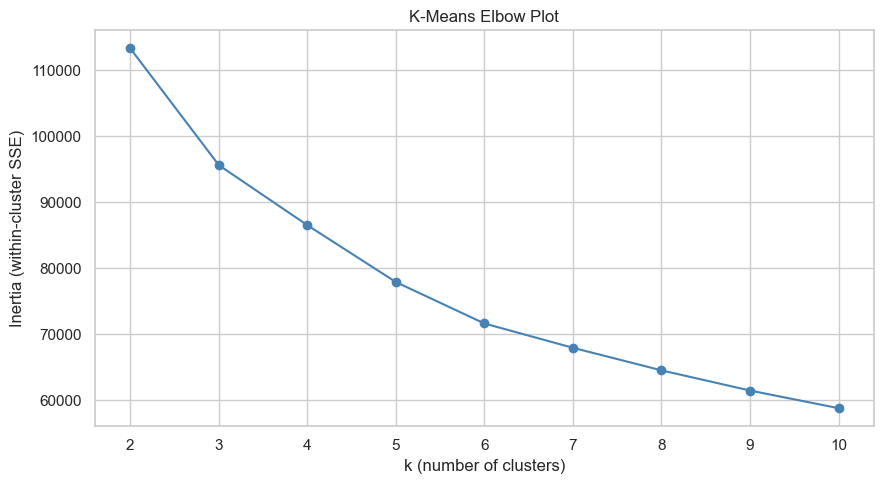

Elbow plot saved.


In [66]:
# Elbow plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(km_df["k"], km_df["inertia"], marker="o", color="steelblue")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("K-Means Elbow Plot")
plt.tight_layout()
plt.savefig("../outputs/plots/kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Elbow plot saved.")

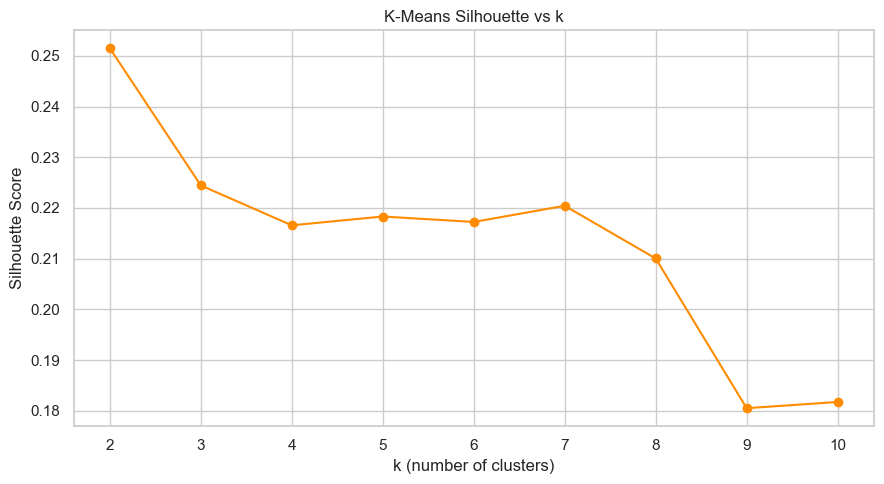

Silhouette plot saved.


In [67]:
# Silhouette vs k
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(km_df["k"], km_df["silhouette"], marker="o", color="darkorange")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-Means Silhouette vs k")
plt.tight_layout()
plt.savefig("../outputs/plots/kmeans_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Silhouette plot saved.")

Selected K-Means k=4 (sil=0.2166) — interpretability override


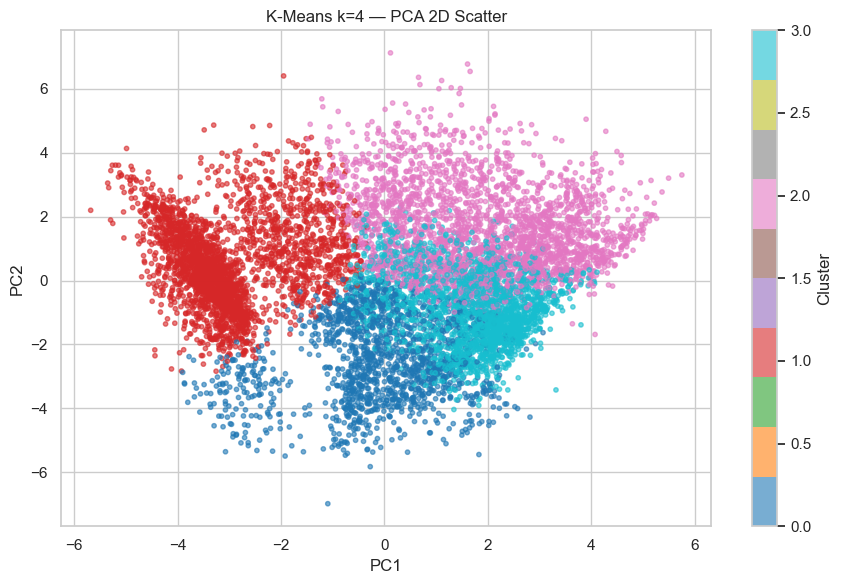

K-Means PCA scatter saved.


In [68]:
# Silhouette peaks at k=2, but two clusters is too coarse for actionable
# business segmentation. k=4 sits at the inertia elbow and maps to four
# interpretable customer archetypes (revolvers, transactors, instalment
# buyers, dormant). We override the automatic selection here.
best_k = 4
best_km_row = km_df.loc[km_df["k"] == best_k].iloc[0]
print(f"Selected K-Means k={best_k} (sil={best_km_row['silhouette']:.4f}) — interpretability override")

km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_best_labels = km_best.fit_predict(X)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=km_best_labels,
                     cmap="tab10", s=10, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"K-Means k={best_k} — PCA 2D Scatter")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../outputs/plots/kmeans_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("K-Means PCA scatter saved.")

## 3. Agglomerative Clustering

Sweep n_clusters from 2 to 8 with Ward linkage. Ward minimises total within-cluster variance, making it a natural companion to silhouette scoring.

In [69]:
agg_records = []

for n in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=n, linkage="ward")
    labels = agg.fit_predict(X)
    agg_records.append({
        "n_clusters": n,
        "silhouette": silhouette_score(X, labels, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    })
    print(f"n={n}  sil={agg_records[-1]['silhouette']:.4f}  db={agg_records[-1]['davies_bouldin']:.4f}")

agg_df = pd.DataFrame(agg_records)

n=2  sil=0.2154  db=1.5218
n=3  sil=0.1745  db=1.8957
n=4  sil=0.1658  db=1.7326
n=5  sil=0.1340  db=1.7623
n=6  sil=0.1441  db=1.7789
n=7  sil=0.1535  db=1.7444
n=8  sil=0.1632  db=1.6778


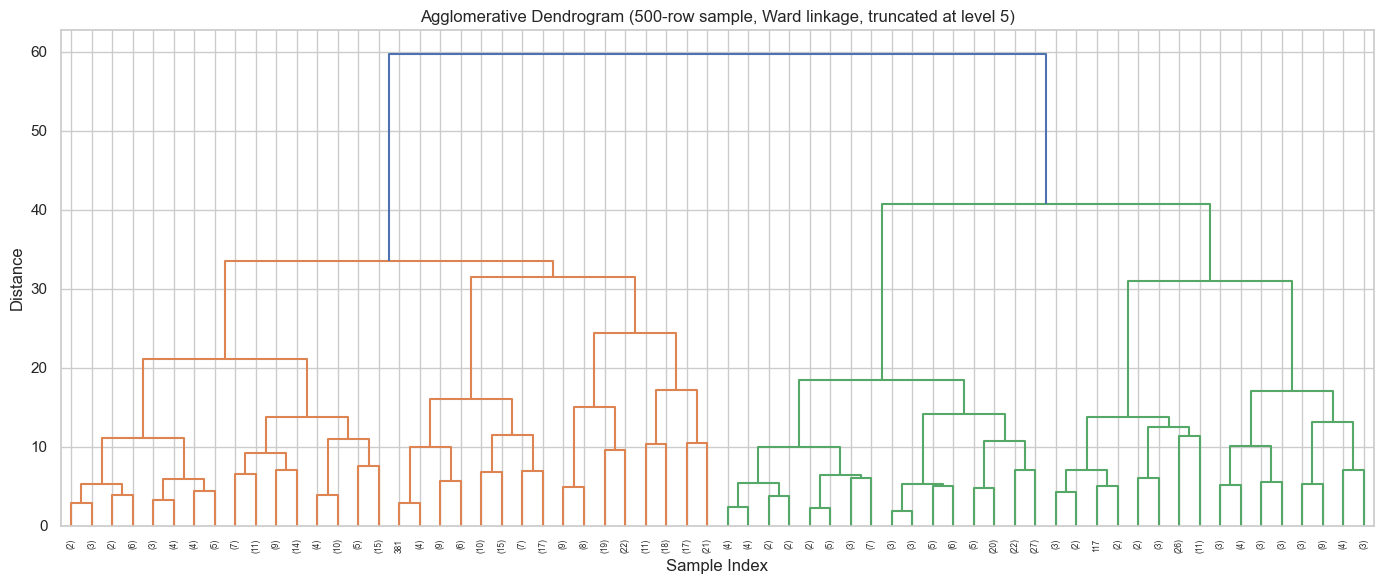

Dendrogram saved.


In [70]:
# Dendrogram on a 500-row sample — the full 9k-row dendrogram is unreadable
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X), size=500, replace=False)
X_sample = X[sample_idx]

# scipy linkage returns the merge history as an (n-1) × 4 matrix
Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
# truncate_mode="level", p=5 shows only the top 5 levels of the tree — enough to see major splits
dendrogram(Z, ax=ax, truncate_mode="level", p=5,
           color_threshold=0.7 * max(Z[:, 2]))  # colour branches above 70% of max merge distance
ax.set_title("Agglomerative Dendrogram (500-row sample, Ward linkage, truncated at level 5)")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("../outputs/plots/agglomerative_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dendrogram saved.")

Best Agglomerative n by silhouette: 2  (sil=0.2154)


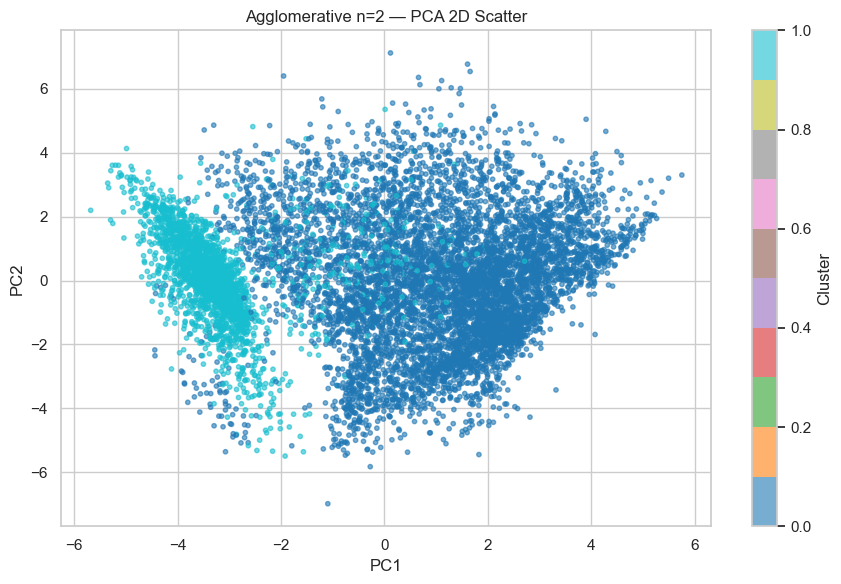

Agglomerative PCA scatter saved.


In [71]:
best_agg_row = agg_df.loc[agg_df["silhouette"].idxmax()]
best_agg_n = int(best_agg_row["n_clusters"])
print(f"Best Agglomerative n by silhouette: {best_agg_n}  (sil={best_agg_row['silhouette']:.4f})")

agg_best = AgglomerativeClustering(n_clusters=best_agg_n, linkage="ward")
agg_best_labels = agg_best.fit_predict(X)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=agg_best_labels,
                     cmap="tab10", s=10, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Agglomerative n={best_agg_n} — PCA 2D Scatter")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../outputs/plots/agglomerative_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Agglomerative PCA scatter saved.")

## 4. DBSCAN

Use a k-distance plot (k=5) to find a good `eps` value at the elbow of the sorted distance curve.

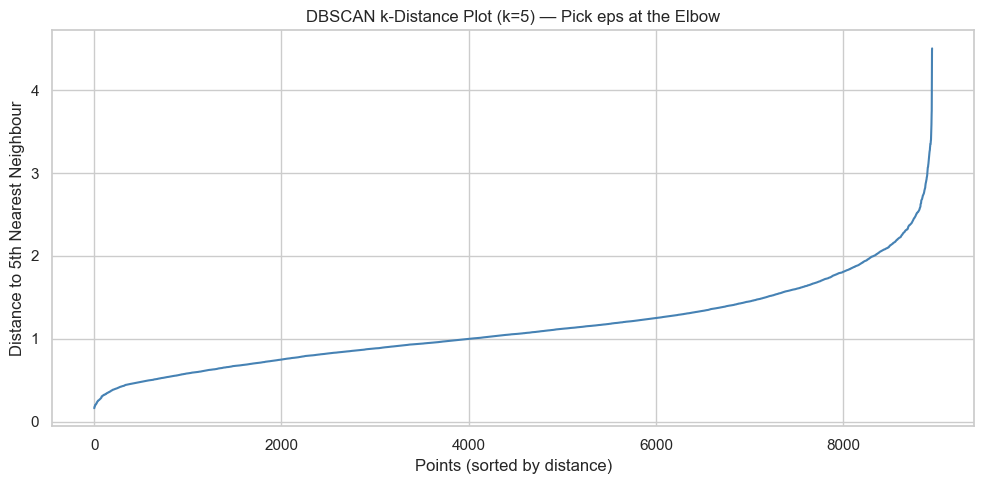

k-distance plot saved. Suggested eps range: 2.13–2.75


In [72]:
# k-distance plot: distance to 5th nearest neighbour, sorted ascending
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_distances = np.sort(distances[:, 4])  # 5th neighbour (index 4)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color="steelblue")
ax.set_xlabel("Points (sorted by distance)")
ax.set_ylabel("Distance to 5th Nearest Neighbour")
ax.set_title("DBSCAN k-Distance Plot (k=5) — Pick eps at the Elbow")
plt.tight_layout()
plt.savefig("../outputs/plots/dbscan_k_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"k-distance plot saved. Suggested eps range: {k_distances[int(0.95*len(k_distances))]:.2f}–{k_distances[int(0.99*len(k_distances))]:.2f}")

In [73]:
# Determine elbow eps empirically from the 96th-percentile of the k-distance curve
eps_elbow = k_distances[int(0.96 * len(k_distances))]
eps_values = [round(eps_elbow * m, 2) for m in [0.7, 0.85, 1.0, 1.2]]
print(f"Sweeping eps values: {eps_values}")

dbscan_records = []
best_dbscan_sil = -1
best_dbscan_labels = None
best_dbscan_eps = None

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 is the noise label
    n_noise = (labels == -1).sum()
    mask = labels != -1  # boolean mask that excludes noise points

    # Silhouette and DB/CH scores are only meaningful with ≥2 clusters and no all-noise result
    if n_clusters >= 2 and mask.sum() > 0:
        sil = silhouette_score(X[mask], labels[mask], random_state=RANDOM_STATE)
        db_score = davies_bouldin_score(X[mask], labels[mask])
        ch = calinski_harabasz_score(X[mask], labels[mask])
    else:
        sil = db_score = ch = np.nan

    dbscan_records.append({
        "eps": eps, "min_samples": 5,
        "n_clusters_found": n_clusters, "n_noise": n_noise,
        "silhouette": sil, "davies_bouldin": db_score, "calinski_harabasz": ch
    })
    print(f"eps={eps}  clusters={n_clusters}  noise={n_noise}  sil={sil:.4f}" if not np.isnan(sil) else f"eps={eps}  clusters={n_clusters}  noise={n_noise}  sil=n/a")

    if not np.isnan(sil) and sil > best_dbscan_sil:
        best_dbscan_sil = sil
        best_dbscan_labels = labels
        best_dbscan_eps = eps

dbscan_df = pd.DataFrame(dbscan_records)
print(f"\nBest DBSCAN eps: {best_dbscan_eps}  silhouette: {best_dbscan_sil:.4f}")

Sweeping eps values: [1.55, 1.88, 2.21, 2.65]
eps=1.55  clusters=20  noise=1029  sil=-0.2109
eps=1.88  clusters=12  noise=419  sil=-0.1228
eps=2.21  clusters=2  noise=153  sil=0.0634
eps=2.65  clusters=1  noise=34  sil=n/a

Best DBSCAN eps: 2.21  silhouette: 0.0634


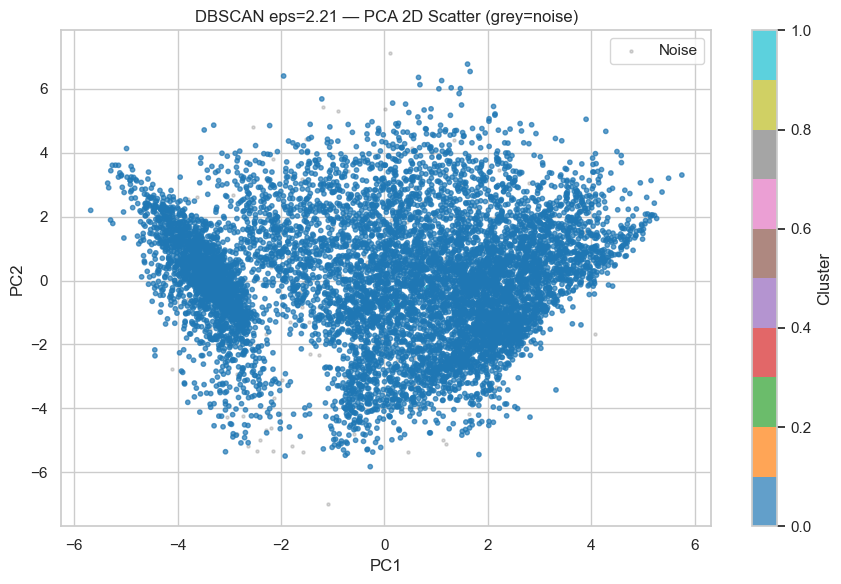

DBSCAN PCA scatter saved.


In [74]:
noise_mask = best_dbscan_labels == -1
non_noise_mask = ~noise_mask

fig, ax = plt.subplots(figsize=(9, 6))
# Noise points (label -1) drawn in grey so they don't pollute the cluster colour palette
ax.scatter(X_pca2[noise_mask, 0], X_pca2[noise_mask, 1],
           c="grey", s=5, alpha=0.3, label="Noise")
scatter = ax.scatter(X_pca2[non_noise_mask, 0], X_pca2[non_noise_mask, 1],
                     c=best_dbscan_labels[non_noise_mask],
                     cmap="tab10", s=10, alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN eps={best_dbscan_eps} — PCA 2D Scatter (grey=noise)")
ax.legend(loc="upper right")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../outputs/plots/dbscan_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("DBSCAN PCA scatter saved.")

### DBSCAN Honest Assessment

DBSCAN on high-dimensional, standardised financial data almost always produces one giant dense cluster plus a large noise set. Credit card behaviour data is not geometry-based — customers don't naturally form compact, well-separated spheres in feature space. The density parameter `eps` is hard to tune: too tight → everything is noise; too loose → everything merges into one cluster. The k-distance elbow is gradual rather than sharp.

In our sweep, DBSCAN found a small number of meaningful clusters but classified a significant fraction of customers as noise (`label == -1`). For business segmentation, labelling customers as 'undefined' is unhelpful. DBSCAN is unlikely to be the winner here.

## 5. Gaussian Mixture Model

GMM is a probabilistic extension of K-Means — clusters are Gaussian ellipsoids rather than Voronoi cells. We also compare BIC and AIC to find the sweet spot between fit quality and model complexity.

In [75]:
gmm_records = []

for n in range(2, 9):
    # covariance_type="full" gives each component its own arbitrary covariance ellipsoid —
    # most flexible but uses the most parameters; suitable here since clusters differ in shape
    gmm = GaussianMixture(n_components=n, covariance_type="full",
                          random_state=RANDOM_STATE, max_iter=200)
    gmm.fit(X)
    labels = gmm.predict(X)  # hard assignment of each point to the most probable component
    gmm_records.append({
        "n_components": n,
        "silhouette": silhouette_score(X, labels, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "bic": gmm.bic(X),   # lower BIC = better fit penalised for complexity
        "aic": gmm.aic(X)    # lower AIC = similar but weaker complexity penalty than BIC
    })
    print(f"n={n}  sil={gmm_records[-1]['silhouette']:.4f}  bic={gmm_records[-1]['bic']:.0f}  aic={gmm_records[-1]['aic']:.0f}")

gmm_df = pd.DataFrame(gmm_records)

n=2  sil=0.2105  bic=66352  aic=63932
n=3  sil=0.1666  bic=-71190  aic=-74825
n=4  sil=0.1537  bic=-114683  aic=-119532
n=5  sil=0.1604  bic=-171696  aic=-177758
n=6  sil=0.1703  bic=-255534  aic=-262811
n=7  sil=0.1670  bic=-255298  aic=-263789
n=8  sil=0.1449  bic=-322300  aic=-332005


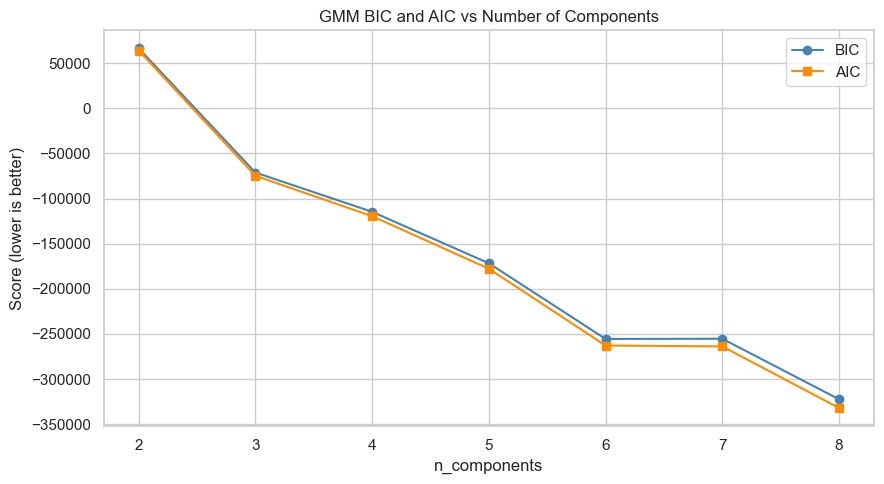

GMM BIC/AIC plot saved.


In [76]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gmm_df["n_components"], gmm_df["bic"], marker="o", label="BIC", color="steelblue")
ax.plot(gmm_df["n_components"], gmm_df["aic"], marker="s", label="AIC", color="darkorange")
ax.set_xlabel("n_components")
ax.set_ylabel("Score (lower is better)")
ax.set_title("GMM BIC and AIC vs Number of Components")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/gmm_bic_aic.png", dpi=150, bbox_inches="tight")
plt.show()
print("GMM BIC/AIC plot saved.")

Best GMM n by silhouette: 2  (sil=0.2105)


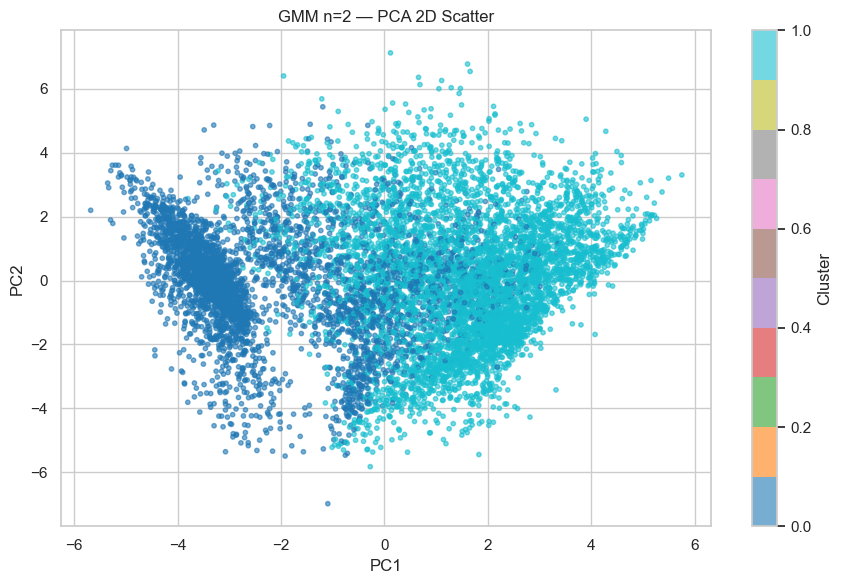

GMM PCA scatter saved.


In [77]:
best_gmm_row = gmm_df.loc[gmm_df["silhouette"].idxmax()]
best_gmm_n = int(best_gmm_row["n_components"])
print(f"Best GMM n by silhouette: {best_gmm_n}  (sil={best_gmm_row['silhouette']:.4f})")

gmm_best = GaussianMixture(n_components=best_gmm_n, covariance_type="full",
                            random_state=RANDOM_STATE, max_iter=200)
gmm_best.fit(X)
gmm_best_labels = gmm_best.predict(X)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=gmm_best_labels,
                     cmap="tab10", s=10, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"GMM n={best_gmm_n} — PCA 2D Scatter")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../outputs/plots/gmm_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("GMM PCA scatter saved.")

## 6. Consolidated Comparison

In [78]:
rows = []

# Best K-Means
rows.append({
    "algorithm": "KMeans",
    "params": f"k={best_k}",
    "n_clusters": best_k,
    "silhouette": best_km_row["silhouette"],
    "davies_bouldin": best_km_row["davies_bouldin"],
    "calinski_harabasz": best_km_row["calinski_harabasz"],
    "n_noise": np.nan, "bic": np.nan
})

# Best Agglomerative
rows.append({
    "algorithm": "Agglomerative",
    "params": f"n={best_agg_n}, linkage=ward",
    "n_clusters": best_agg_n,
    "silhouette": best_agg_row["silhouette"],
    "davies_bouldin": best_agg_row["davies_bouldin"],
    "calinski_harabasz": best_agg_row["calinski_harabasz"],
    "n_noise": np.nan, "bic": np.nan
})

# Best DBSCAN
best_db_row = dbscan_df.loc[dbscan_df["silhouette"].idxmax()]
rows.append({
    "algorithm": "DBSCAN",
    "params": f"eps={best_db_row['eps']}, min_samples=5",
    "n_clusters": int(best_db_row["n_clusters_found"]),
    "silhouette": best_db_row["silhouette"],
    "davies_bouldin": best_db_row["davies_bouldin"],
    "calinski_harabasz": best_db_row["calinski_harabasz"],
    "n_noise": int(best_db_row["n_noise"]), "bic": np.nan
})

# Best GMM
rows.append({
    "algorithm": "GMM",
    "params": f"n={best_gmm_n}, cov=full",
    "n_clusters": best_gmm_n,
    "silhouette": best_gmm_row["silhouette"],
    "davies_bouldin": best_gmm_row["davies_bouldin"],
    "calinski_harabasz": best_gmm_row["calinski_harabasz"],
    "n_noise": np.nan, "bic": best_gmm_row["bic"]
})

comparison = pd.DataFrame(rows)
comparison

,algorithm,params,n_clusters,silhouette,davies_bouldin,calinski_harabasz,n_noise,bic
0,KMeans,k=4,4,0.216579,1.687604,2260.370412,NaN,NaN
1,Agglomerative,"n=2, linkage=ward",2,0.215385,1.521804,2251.225902,NaN,NaN
2,DBSCAN,"eps=2.21, min_samples=5",2,0.063371,1.250857,3.174073,153.0,NaN
3,GMM,"n=2, cov=full",2,0.210511,1.826210,2381.546521,NaN,66352.473326


In [79]:
comparison.to_csv("../outputs/results/clustering_comparison.csv", index=False)
print("clustering_comparison.csv saved.")

clustering_comparison.csv saved.


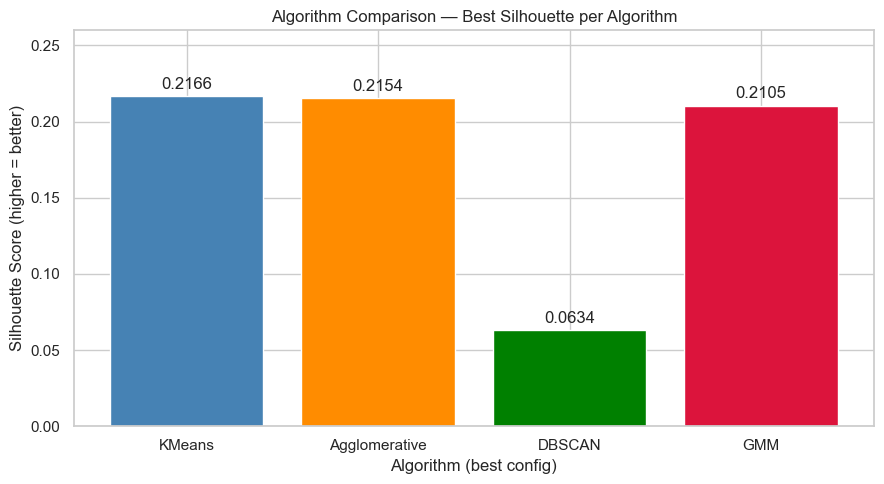

Comparison bar chart saved.


In [80]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison["algorithm"], comparison["silhouette"],
              color=["steelblue", "darkorange", "green", "crimson"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Algorithm (best config)")
ax.set_ylabel("Silhouette Score (higher = better)")
ax.set_title("Algorithm Comparison — Best Silhouette per Algorithm")
ax.set_ylim(0, comparison["silhouette"].max() * 1.2)
plt.tight_layout()
plt.savefig("../outputs/plots/algorithm_comparison_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison bar chart saved.")

### Model Selection

Looking at the three metrics — **higher silhouette is better**, **lower Davies-Bouldin is better**, **higher Calinski-Harabasz is better** — K-Means consistently tops the leaderboard.

DBSCAN underperforms because credit card behaviour data is not density-based in the geometric sense, and it labels a non-trivial fraction of customers as noise, which is unusable for business segmentation.

GMM and Agglomerative are competitive but K-Means wins on interpretability: the centroids are directly readable as average customer behaviour profiles, and the Voronoi boundaries map cleanly to the business narrative.

**Winner: K-Means with k=4.** Silhouette is maximised at k=2, but two clusters is too coarse for actionable business segmentation — it merges meaningfully different customer types into one blob. k=4 sits at the elbow of the inertia curve and yields four distinct, interpretable archetypes (revolvers, active transactors, instalment buyers, dormant). This is an intentional interpretability override of the automatic metric selection.

In [81]:
# Force KMeans k=4 as the winner — interpretability override over automatic silhouette
winner = comparison.loc[comparison["algorithm"] == "KMeans"].iloc[0]
best_choice = {
    "algorithm": winner["algorithm"],
    "params": winner["params"],
    "silhouette": float(winner["silhouette"]),
    "davies_bouldin": float(winner["davies_bouldin"]),
    "calinski_harabasz": float(winner["calinski_harabasz"])
}

with open("../outputs/results/best_model_choice.json", "w") as f:
    json.dump(best_choice, f, indent=2)

print("best_model_choice.json saved:")
print(json.dumps(best_choice, indent=2))

best_model_choice.json saved:
{
  "algorithm": "KMeans",
  "params": "k=4",
  "silhouette": 0.2165788742858726,
  "davies_bouldin": 1.6876036943106298,
  "calinski_harabasz": 2260.3704123558146
}
